# Librerías

In [169]:
import sys
!{sys.executable} -m pip install imbalanced-learn
!{sys.executable} -m pip install shap
!{sys.executable} -m pip install lime


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [283]:
import pandas as pd
import numpy as np
import matplotlib as plt
import seaborn as sns

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import balanced_accuracy_score
from sklearn.metrics import classification_report
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline 

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier

from sklearn.feature_selection import RFE
from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.model_selection import GridSearchCV

import shap
from lime import lime_tabular
from IPython.display import HTML

from scipy.stats import wilcoxon
import warnings
warnings.filterwarnings('ignore')

# PRE-ANÁLISIS

In [171]:
datos = pd.read_csv("diabetic_data.csv")

In [172]:
# display(datos.head()) # primeras 5
# display(datos.dtypes) # tipos
# datos.describe(include='all') # analiza media, std etc
# display(datos.isnull().any()) # valores null
display(datos.info())
# datos.describe()
# display(datos)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

None

In [173]:
datos["readmitted"] = datos["readmitted"].astype("category")
datos["readmitted"] = datos["readmitted"].map({
    "<30": 1,
    ">30": 0,
    "NO": 0
})

In [174]:
# Reemplazar los valores "?" por NaN (not a number)
datos = datos.replace("?", np.nan)
datos = datos.replace("None", np.nan)


In [175]:
# Quitar IDs (innecesarios para el análisis) y columnas con muchos valores faltantes
datos = datos.drop(columns=['encounter_id', 'patient_nbr'])
datos = datos.drop(columns=['weight'])
datos = datos.drop(columns=['max_glu_serum'])
datos = datos.drop(columns=['A1Cresult'])
datos = datos.drop(columns=['medical_specialty'])
datos = datos.drop(columns=['payer_code'])


Codificar variables categóricas

In [176]:
datos["race"].value_counts() # V. Categórica sin orden, usamos one-hot encoding

race
Caucasian          76099
AfricanAmerican    19210
Hispanic            2037
Other               1506
Asian                641
Name: count, dtype: int64

In [177]:
datos = pd.get_dummies(datos, columns=['race'], drop_first=True)

In [178]:
datos["gender"].value_counts() # V. Categórica sin orden, usamos one-hot encoding

gender
Female             54708
Male               47055
Unknown/Invalid        3
Name: count, dtype: int64

In [179]:
datos = pd.get_dummies(datos, columns=['gender'], drop_first=True)

In [180]:
datos["age"].value_counts() # V. Categórica con orden, mapearé con valor medio de cada rango

age
[70-80)     26068
[60-70)     22483
[50-60)     17256
[80-90)     17197
[40-50)      9685
[30-40)      3775
[90-100)     2793
[20-30)      1657
[10-20)       691
[0-10)        161
Name: count, dtype: int64

In [181]:
datos["age"] = datos["age"].map({
    "[0-10)": 5,
    "[10-20)": 15,
    "[20-30)": 25,
    "[30-40)": 35,
    "[40-50)": 45,
    "[50-60)": 55,
    "[60-70)": 65,
    "[70-80)": 75,
    "[80-90)": 85,
    "[90-100)": 95
})

In [182]:
display(datos['diag_1'].value_counts().head()) # |
display(datos['diag_2'].value_counts().head()) # | Como tiene tantas categorías, se agruparán por sistemas.
display(datos['diag_3'].value_counts().head()) # |

diag_1
428    6862
414    6581
786    4016
410    3614
486    3508
Name: count, dtype: int64

diag_2
276    6752
428    6662
250    6071
427    5036
401    3736
Name: count, dtype: int64

diag_3
250    11555
401     8289
276     5175
428     4577
427     3955
Name: count, dtype: int64

In [183]:
def seleccionarDiagnostico(codigo):
    cod = str(codigo).strip()
    try:
        codigoFloat = float(cod)
        if 390 <= codigoFloat <= 459 or codigoFloat == 785:
            return 'Circulatorio'
        elif 460 <= codigoFloat <= 519 or codigoFloat == 786:
            return 'Respiratorio'
        elif 520 <= codigoFloat <= 579 or codigoFloat == 787:
            return 'Digestivo'
        elif 250 <= codigoFloat < 251: # Diabetes es 250.xx
            return 'Diabetes'
        elif 800 <= codigoFloat <= 999:
            return 'Lesiones'
        elif 710 <= codigoFloat <= 739:
            return 'Musculoesquelético'
        elif 580 <= codigoFloat <= 629 or codigoFloat == 788:
            return 'Genitourinario'
        elif 140 <= codigoFloat <= 239:
            return 'Neoplasias'
        else:
            return 'Otros'
    except:
        return "Otros"

for col in ['diag_1', 'diag_2', 'diag_3']:
    datos[col] = datos[col].apply(seleccionarDiagnostico)
    datos = pd.get_dummies(datos, columns=[col], drop_first=True)


In [184]:
datos["metformin"].value_counts() 

metformin
No        81778
Steady    18346
Up         1067
Down        575
Name: count, dtype: int64

In [185]:
datos["metformin"] = datos["metformin"].map({
    "No": 0,
    "Down": 1,
    "Steady": 2,
    "Up": 3
})

In [186]:
datos["repaglinide"].value_counts(normalize="True") 

repaglinide
No        0.984877
Steady    0.013600
Up        0.001081
Down      0.000442
Name: proportion, dtype: float64

In [187]:
datos = datos.drop(columns=['repaglinide'])

In [188]:
datos["nateglinide"].value_counts(normalize="True") 

nateglinide
No        0.993092
Steady    0.006564
Up        0.000236
Down      0.000108
Name: proportion, dtype: float64

In [189]:
datos = datos.drop(columns=['nateglinide'])

In [190]:
datos["chlorpropamide"].value_counts(normalize="True") 

chlorpropamide
No        0.999155
Steady    0.000776
Up        0.000059
Down      0.000010
Name: proportion, dtype: float64

In [191]:
datos = datos.drop(columns=['chlorpropamide'])

In [192]:
datos["glimepiride"].value_counts(normalize="True") 

glimepiride
No        0.948991
Steady    0.045890
Up        0.003213
Down      0.001906
Name: proportion, dtype: float64

In [193]:
datos["glimepiride"] = datos["glimepiride"].map({
    "No": 0,
    "Down": 1,
    "Steady": 2,
    "Up": 3
})

In [194]:
datos["acetohexamide"].value_counts(normalize="True") 

acetohexamide
No        0.99999
Steady    0.00001
Name: proportion, dtype: float64

In [195]:
datos = datos.drop(columns=['acetohexamide'])

In [196]:
datos["glipizide"].value_counts(normalize="True") 

glipizide
No        0.875341
Steady    0.111589
Up        0.007566
Down      0.005503
Name: proportion, dtype: float64

In [197]:
datos["glipizide"] = datos["glipizide"].map({
    "No": 0,
    "Down": 1,
    "Steady": 2,
    "Up": 3
})

In [198]:
datos["glyburide"].value_counts(normalize="True") 

glyburide
No        0.895348
Steady    0.091131
Up        0.007979
Down      0.005542
Name: proportion, dtype: float64

In [199]:
datos["glyburide"] = datos["glyburide"].map({
    "No": 0,
    "Down": 1,
    "Steady": 2,
    "Up": 3
})

In [200]:
datos["tolbutamide"].value_counts(normalize="True") 

tolbutamide
No        0.999774
Steady    0.000226
Name: proportion, dtype: float64

In [201]:
datos = datos.drop(columns=['tolbutamide'])

In [202]:
datos["pioglitazone"].value_counts(normalize="True") 

pioglitazone
No        0.927992
Steady    0.068549
Up        0.002299
Down      0.001160
Name: proportion, dtype: float64

In [203]:
datos["pioglitazone"] = datos["pioglitazone"].map({
    "No": 0,
    "Down": 1,
    "Steady": 2,
    "Up": 3
})

In [204]:
datos["rosiglitazone"].value_counts(normalize="True") 

rosiglitazone
No        0.937455
Steady    0.059941
Up        0.001749
Down      0.000855
Name: proportion, dtype: float64

In [205]:
datos["rosiglitazone"] = datos["rosiglitazone"].map({
    "No": 0,
    "Down": 1,
    "Steady": 2,
    "Up": 3
})

In [206]:
datos["acarbose"].value_counts(normalize="True") 

acarbose
No        0.996973
Steady    0.002899
Up        0.000098
Down      0.000029
Name: proportion, dtype: float64

In [207]:
datos = datos.drop(columns=['acarbose'])

In [208]:
datos["miglitol"].value_counts(normalize="True") 

miglitol
No        0.999627
Steady    0.000305
Down      0.000049
Up        0.000020
Name: proportion, dtype: float64

In [209]:
datos = datos.drop(columns=['miglitol'])

In [210]:
datos["troglitazone"].value_counts(normalize="True") 

troglitazone
No        0.999971
Steady    0.000029
Name: proportion, dtype: float64

In [211]:
datos = datos.drop(columns=['troglitazone'])

In [212]:
datos["tolazamide"].value_counts(normalize="True") 

tolazamide
No        0.999617
Steady    0.000373
Up        0.000010
Name: proportion, dtype: float64

In [213]:
datos = datos.drop(columns=['tolazamide'])

In [214]:
datos["examide"].value_counts(normalize="True") 

examide
No    1.0
Name: proportion, dtype: float64

In [215]:
datos = datos.drop(columns=['examide'])

In [216]:
datos["citoglipton"].value_counts(normalize="True") 

citoglipton
No    1.0
Name: proportion, dtype: float64

In [217]:
datos = datos.drop(columns=['citoglipton'])

In [218]:
datos["insulin"].value_counts(normalize="True") 

insulin
No        0.465607
Steady    0.303137
Down      0.120060
Up        0.111196
Name: proportion, dtype: float64

In [219]:
datos["insulin"] = datos["insulin"].map({
    "No": 0,
    "Down": 1,
    "Steady": 2,
    "Up": 3
})

In [220]:
datos["glyburide-metformin"].value_counts(normalize="True") 

glyburide-metformin
No        0.993063
Steady    0.006800
Up        0.000079
Down      0.000059
Name: proportion, dtype: float64

In [221]:
datos = datos.drop(columns=['glyburide-metformin'])

In [222]:
datos["glipizide-metformin"].value_counts(normalize="True") 

glipizide-metformin
No        0.999872
Steady    0.000128
Name: proportion, dtype: float64

In [223]:
datos = datos.drop(columns=['glipizide-metformin'])

In [224]:
datos["glimepiride-pioglitazone"].value_counts(normalize="True") 

glimepiride-pioglitazone
No        0.99999
Steady    0.00001
Name: proportion, dtype: float64

In [225]:
datos = datos.drop(columns=['glimepiride-pioglitazone'])

In [226]:
datos["metformin-rosiglitazone"].value_counts(normalize="True") 

metformin-rosiglitazone
No        0.99998
Steady    0.00002
Name: proportion, dtype: float64

In [227]:
datos = datos.drop(columns=['metformin-rosiglitazone'])

In [228]:
datos["metformin-pioglitazone"].value_counts(normalize="True") 

metformin-pioglitazone
No        0.99999
Steady    0.00001
Name: proportion, dtype: float64

In [229]:
datos = datos.drop(columns=['metformin-pioglitazone'])

In [230]:
datos["change"].value_counts(normalize="True") 

change
No    0.538048
Ch    0.461952
Name: proportion, dtype: float64

In [231]:
datos["change"] = datos["change"].map({
    "No": 0,
    "Ch": 1
})

In [232]:
datos["diabetesMed"].value_counts(normalize="True") 

diabetesMed
Yes    0.770031
No     0.229969
Name: proportion, dtype: float64

In [233]:
datos["diabetesMed"] = datos["diabetesMed"].map({
    "No": 0,
    "Yes": 1
})

In [234]:
datos["insulin"].value_counts()

insulin
0    47383
2    30849
1    12218
3    11316
Name: count, dtype: int64

In [235]:
def transformarAdmTypeId(valor):
    val = str(valor).strip()
    try:
        int(val)
        if valor in [1,2,7]:
            return "Urgencia"
        elif valor == 3:
            return 'Electivo'
        elif valor == 4:
            return 'Recien_Nacido'
        else:
            return 'Otro'
    except:
        return 'Otro'

datos["admission_type_id"] = datos["admission_type_id"].apply(transformarAdmTypeId)
datos = pd.get_dummies(datos, columns=['admission_type_id'], drop_first=True)

In [236]:
# 1. Primero eliminamos los fallecidos (imprescindible)
fallecidos = [11, 13, 14, 19, 20, 21]
datos = datos[~datos['discharge_disposition_id'].isin(fallecidos)] # PREGUNTAR

def agruparDischarge(id):
    if id in [1, 6, 8]:
        return 'Hogar'
    elif id in [2, 3, 4, 5, 9, 10, 15, 22, 23, 24, 27, 28, 29, 30]:
        return 'Traslado'
    else:
        return 'Otros_Desconocido'

datos['discharge_disposition_id'] = datos['discharge_disposition_id'].apply(agruparDischarge)
datos = pd.get_dummies(datos, columns=['discharge_disposition_id'], drop_first=True)

In [237]:
def agruparOrigen(id):
    if id in [1, 2, 3]:
        return 'Referido'
    elif id in [4, 5, 6, 10, 18, 19, 22, 25, 26]:
        return 'Traslado'
    elif id == 7:
        return 'Urgencias'
    else:
        return 'Otros_Desconocido'

datos['admission_source_id'] = datos['admission_source_id'].apply(agruparOrigen)
datos = pd.get_dummies(datos, columns=['admission_source_id'], drop_first=True)

In [238]:
# onehot transformamos de bool a int
datos = datos.astype({col: int for col in datos.select_dtypes('bool').columns})

In [239]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
Index: 99343 entries, 0 to 101765
Data columns (total 57 columns):
 #   Column                                      Non-Null Count  Dtype
---  ------                                      --------------  -----
 0   age                                         99343 non-null  int64
 1   time_in_hospital                            99343 non-null  int64
 2   num_lab_procedures                          99343 non-null  int64
 3   num_procedures                              99343 non-null  int64
 4   num_medications                             99343 non-null  int64
 5   number_outpatient                           99343 non-null  int64
 6   number_emergency                            99343 non-null  int64
 7   number_inpatient                            99343 non-null  int64
 8   number_diagnoses                            99343 non-null  int64
 9   metformin                                   99343 non-null  int64
 10  glimepiride                           

# EDA

In [240]:
# _ = datos.hist(figsize=(30, 30))

## Cuantficación objetivo

In [241]:
conteo = datos['readmitted'].value_counts()
porcentaje = datos['readmitted'].value_counts(normalize=True) * 100

print(f"Clase 0 (No readmitido): {conteo[0]} registros ({porcentaje[0]:.2f}%)")
print(f"Clase 1 (Readmitido): {conteo[1]} registros ({porcentaje[1]:.2f}%)")

Clase 0 (No readmitido): 88029 registros (88.61%)
Clase 1 (Readmitido): 11314 registros (11.39%)


In [242]:

# We will plot a subset of the data to keep the plot readable and make the
# plotting faster
# n_samples_to_plot = 10000
# columns = ["age", "time_in_hospital", "num_lab_procedures", "num_medications"]
# _ = sns.pairplot(
#     data=datos[:n_samples_to_plot],
#     vars=columns,
#     hue="readmitted",
#     plot_kws={"alpha": 0.2},
#     height=3,
#     diag_kind="hist",
#     diag_kws={"bins": 30},
# )

In [243]:

# # We will plot a subset of the data to keep the plot readable and make the
# # plotting faster
# n_samples_to_plot = 10000
# columns = ["number_inpatient", "number_emergency", "number_outpatient", "number_diagnoses"]
# _ = sns.pairplot(
#     data=datos[:n_samples_to_plot],
#     vars=columns,
#     hue="readmitted",
#     plot_kws={"alpha": 0.2},
#     height=3,
#     diag_kind="hist",
#     diag_kws={"bins": 30},
# )

In [244]:
y = datos["readmitted"]
X = datos.drop(columns=["readmitted"])

In [245]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [246]:
dummy_classifier = DummyClassifier(strategy="most_frequent")
dummy_classifier.fit(X_train, y_train)
print(f"Accuracy del dummy classifier: "
      f"{dummy_classifier.score(X_test, y_test):.3f}")

Accuracy del dummy classifier: 0.886


In [247]:
balanced_accuracy = balanced_accuracy_score(y_test, dummy_classifier.predict(X_test))
print(f"Balanced accuracy: {balanced_accuracy:.3f}")

Balanced accuracy: 0.500


In [248]:
scores = cross_val_score(dummy_classifier, X_train, y_train, cv=10, scoring='balanced_accuracy')

print(f"Balanced Accuracy medio (10-CV): {scores.mean():.3f}")

Balanced Accuracy medio (10-CV): 0.500


## Modelado inicial

In [249]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn_model = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)

knn_model.fit(X_train_scaled, y_train)
y_pred_knn = knn_model.predict(X_test_scaled)

print(f"Balanced Accuracy K-NN: {balanced_accuracy_score(y_test, y_pred_knn):.3f}")
print(classification_report(y_test, y_pred_knn))

Balanced Accuracy K-NN: 0.510
              precision    recall  f1-score   support

           0       0.89      0.99      0.93     17606
           1       0.24      0.03      0.06      2263

    accuracy                           0.88     19869
   macro avg       0.56      0.51      0.50     19869
weighted avg       0.81      0.88      0.83     19869



In [250]:
scores_knn = cross_val_score(knn_model, X_train_scaled, y_train, cv=10, scoring='balanced_accuracy')
print(f"Balanced Accuracy medio K-NN (10-CV): {scores_knn.mean():.3f}")

Balanced Accuracy medio K-NN (10-CV): 0.511


In [251]:
logistic_regression = make_pipeline(
    StandardScaler(), 
    LogisticRegression(penalty=None, class_weight='balanced', max_iter=1000)
)

# Entrenamos
logistic_regression.fit(X_train, y_train)

# Evaluamos
accuracy = logistic_regression.score(X_test, y_test)
y_pred = logistic_regression.predict(X_test)
balanced_acc = balanced_accuracy_score(y_test, y_pred)

print(f"Accuracy en el set de test: {accuracy:.3f}")
print(f"Balanced Accuracy: {balanced_acc:.3f}")
print("\nInforme de Clasificación:")
print(classification_report(y_test, y_pred))


Accuracy en el set de test: 0.665
Balanced Accuracy: 0.610

Informe de Clasificación:
              precision    recall  f1-score   support

           0       0.92      0.68      0.78     17606
           1       0.18      0.54      0.27      2263

    accuracy                           0.67     19869
   macro avg       0.55      0.61      0.53     19869
weighted avg       0.84      0.67      0.72     19869



In [252]:
scores_lr = cross_val_score(logistic_regression, X_train, y_train, cv=10, scoring='balanced_accuracy')
print(f"Balanced Accuracy medio (10-CV): {scores_lr.mean():.3f}")

Balanced Accuracy medio (10-CV): 0.610


## Gestión de desequilibrio
Probar a hacer LogisticRegression con y sin SMOTE.

In [253]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
auc_sin_smote = cross_val_score(logistic_regression, X, y, cv=cv, scoring='roc_auc')

In [254]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

pipeline_smote = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('logreg', LogisticRegression(max_iter=1000))
])

auc_smote = cross_val_score(pipeline_smote, X, y, cv=cv, scoring='roc_auc')

In [255]:
print("AUC sin SMOTE:")
for i in range(len(auc_sin_smote)):
    print(f"Fold {i + 1}: {auc_sin_smote[i]:.3f}")

print(f"Media: {auc_sin_smote.mean():.3f}")

AUC sin SMOTE:
Fold 1: 0.643
Fold 2: 0.663
Fold 3: 0.646
Fold 4: 0.653
Fold 5: 0.661
Fold 6: 0.651
Fold 7: 0.650
Fold 8: 0.666
Fold 9: 0.664
Fold 10: 0.667
Media: 0.656


In [256]:
print("AUC con SMOTE:")
for i in range(len(auc_smote)):
    print(f"Fold {i + 1}: {auc_smote[i]:.3f}")
print(f"Media: {auc_smote.mean():.3f}")

AUC con SMOTE:
Fold 1: 0.624
Fold 2: 0.650
Fold 3: 0.640
Fold 4: 0.646
Fold 5: 0.648
Fold 6: 0.640
Fold 7: 0.636
Fold 8: 0.653
Fold 9: 0.654
Fold 10: 0.655
Media: 0.645


# MÁS MODELOS

## DecisionTreeClassifier

In [257]:
arbol = make_pipeline(
    StandardScaler(),
    DecisionTreeClassifier(max_depth=7, class_weight='balanced', random_state=42)
)
arbol.fit(X_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('decisiontreeclassifier',
                 DecisionTreeClassifier(class_weight='balanced', max_depth=7,
                                        random_state=42))])

In [258]:
scores_dt_acc = cross_val_score(arbol, X, y, cv=10, scoring='accuracy')
scores_dt = cross_val_score(arbol, X, y, cv=10, scoring='balanced_accuracy')

In [259]:
print(f"Decision Tree classifier accuracy: "
      f"{scores_dt_acc.mean():.3f} ± {scores_dt_acc.std():.3f}\n")
print(f"Decision Tree classifier balanced accuracy: "
      f"{scores_dt.mean():.3f} ± {scores_dt.std():.3f}")

Decision Tree classifier accuracy: 0.627 ± 0.039

Decision Tree classifier balanced accuracy: 0.612 ± 0.011


## RandomForestClassifier

In [260]:
random_forest = make_pipeline(
    StandardScaler(),
    RandomForestClassifier(max_depth=7, n_estimators=100, class_weight='balanced', n_jobs=-1, random_state=42)
)

In [261]:
scores_rf_acc = cross_val_score(random_forest, X, y, cv=10, scoring='accuracy')
scores_rf = cross_val_score(random_forest, X, y, cv=10, scoring='balanced_accuracy')

In [262]:
print(f"Random Forest accuracy: "
      f"{scores_rf_acc.mean():.3f} ± {scores_rf_acc.std():.3f}\n")
print(f"Random Forest balanced accuracy: "
      f"{scores_rf.mean():.3f} ± {scores_rf.std():.3f}")

Random Forest accuracy: 0.645 ± 0.048

Random Forest balanced accuracy: 0.618 ± 0.009


## ADABOOST

In [263]:
estimator = DecisionTreeClassifier(max_depth=3, class_weight='balanced', random_state=42)

adaboost = AdaBoostClassifier(
    estimator=estimator,
    n_estimators=10, 
    algorithm="SAMME",
    random_state=42
)

adaboost.fit(X_train, y_train)

AdaBoostClassifier(algorithm='SAMME',
                   estimator=DecisionTreeClassifier(class_weight='balanced',
                                                    max_depth=3,
                                                    random_state=42),
                   n_estimators=10, random_state=42)

In [264]:
print(f"Weight of each classifier: {adaboost.estimator_weights_}")
print(f"Error of each classifier: {adaboost.estimator_errors_}")

Weight of each classifier: [0.38963563 0.         0.         0.         0.         0.
 0.         0.         0.         0.        ]
Error of each classifier: [0.40380502 1.         1.         1.         1.         1.
 1.         1.         1.         1.        ]


In [265]:
scores_ada = cross_val_score(adaboost, X, y, cv=10, scoring='balanced_accuracy')
print(f"\nAdaBoost Balanced Accuracy: {scores_ada.mean():.3f} ± {scores_ada.std():.3f}")


AdaBoost Balanced Accuracy: 0.587 ± 0.023


# Selección de características

## RFE

In [266]:
rf_selector = random_forest.named_steps['randomforestclassifier']
selector_rfe = RFE(estimator=rf_selector, n_features_to_select=10, step=1)

# Ajustamos (solo con X_train para no contaminar)
selector_rfe.fit(X_train, y_train)

# Sacamos los nombres
top_rfe = X_train.columns[selector_rfe.support_].tolist()
print("Top 10 variables (RFE):", top_rfe)

Top 10 variables (RFE): ['age', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'discharge_disposition_id_Traslado']


## SelectKBest

In [267]:
selector_kbest = SelectKBest(score_func=f_classif, k=10)
selector_kbest.fit(X_train, y_train)

top_kbest = X_train.columns[selector_kbest.get_support()].tolist()
print("Top 10 variables (SelectKBest):", top_kbest)

Top 10 variables (SelectKBest): ['time_in_hospital', 'num_lab_procedures', 'num_medications', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'metformin', 'insulin', 'diabetesMed', 'discharge_disposition_id_Traslado']


# Comparación estadística

In [268]:
modelos = {
    'KNN': scores_knn,
    'LogisticRegression': scores_lr,
    'Árbol': scores_dt,
    'AdaBoost': scores_ada
}

# Comparamos todos contra el Random Forest (que fue el mejor)
mejor_modelo = scores_rf
resultados_test = []

for nombre, scores in modelos.items():
    stat, p_val = wilcoxon(mejor_modelo, scores, alternative='greater', zero_method='wilcox', correction=False)
    resultados_test.append({
        'Comparación': f'Random Forest vs {nombre}',
        'Estadístico': stat,
        'p-valor': round(p_val, 4),
        '¿Es significativo?': 'SÍ' if p_val < 0.05 else 'NO'
    })

df_stats = pd.DataFrame(resultados_test)
print(df_stats)

                           Comparación  Estadístico  p-valor  \
0                 Random Forest vs KNN         55.0   0.0010   
1  Random Forest vs LogisticRegression         48.0   0.0186   
2               Random Forest vs Árbol         55.0   0.0010   
3            Random Forest vs AdaBoost         55.0   0.0010   

  ¿Es significativo?  
0                 SÍ  
1                 SÍ  
2                 SÍ  
3                 SÍ  


# Explicabilidad

## SHAP

In [272]:
model_shap = RandomForestClassifier(max_depth=7, n_estimators=100, class_weight='balanced', random_state=42)
model_shap.fit(X_train, y_train)

explainer = shap.TreeExplainer(model_shap)
shap_values = explainer.shap_values(X_test)

if len(shap_values.shape) == 3:
    shap_to_plot = shap_values[:, :, 1]
else:
    shap_to_plot = shap_values

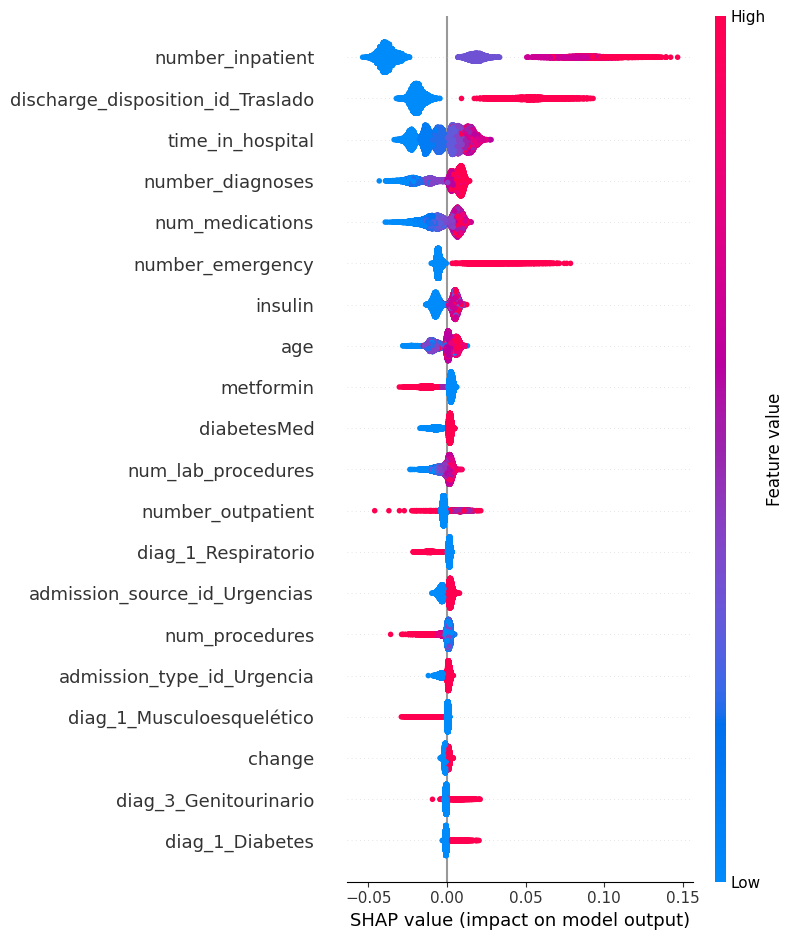

In [273]:
# Gráfico en general
shap.summary_plot(shap_to_plot, X_test)

In [290]:
# Gráfico individual de paciente No Readmitido
shap.initjs()
idx = 0
shap.force_plot(
    explainer.expected_value[1],              
    shap_values[idx, :, 1],                   
    X_test.iloc[idx]            
)

In [291]:
# Gráfico individual de paciente Readmitido
idx = 6000
shap.force_plot(
    explainer.expected_value[1],              
    shap_values[idx, :, 1],                   
    X_test.iloc[idx]            
)

## LIME

In [287]:
cols_finales = X_train.columns[selector_rfe.support_]

rf_final = RandomForestClassifier(
    max_depth=7, 
    n_estimators=100, 
    class_weight='balanced', 
    random_state=42
)
rf_final.fit(X_train[cols_finales], y_train)

explainer_lime = lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train[cols_finales]), 
    feature_names=cols_finales.tolist(),
    class_names=['No Readmitido', 'Readmitido'],
    mode='classification'
)

In [292]:
# Gráfico individual paciente No Readmitido
idx = 0
exp = explainer_lime.explain_instance(
    data_row=X_test[cols_finales].iloc[idx], 
    predict_fn=rf_final.predict_proba
)

html_data = exp.as_html()
HTML(html_data)

In [293]:
# Gráfico individual paciente Readmitido
idx = 6000
exp = explainer_lime.explain_instance(
    data_row=X_test[cols_finales].iloc[idx], 
    predict_fn=rf_final.predict_proba
)

html_data = exp.as_html()
HTML(html_data)

# Mejores Hiperparámetros

In [302]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'class_weight': ['balanced']
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5, 
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
print("Mejores parámetros:", grid_search.best_params_)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Mejores parámetros: {'class_weight': 'balanced', 'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}


In [303]:
mejor_modelo = make_pipeline(
    StandardScaler(),
    RandomForestClassifier(class_weight='balanced', max_depth=10, min_samples_split=5, n_estimators=200, random_state=42)
)

scores_best_model_rf_acc = cross_val_score(mejor_modelo, X, y, cv=10, scoring='accuracy')
scores_best_model_rf = cross_val_score(mejor_modelo, X, y, cv=10, scoring='balanced_accuracy')

In [305]:
print(f"Random Forest accuracy: "
      f"{scores_rf_acc.mean():.3f} ± {scores_rf_acc.std():.3f}\n")
print(f"Random Forest balanced accuracy: "
      f"{scores_rf.mean():.3f} ± {scores_rf.std():.3f}")

Random Forest accuracy: 0.645 ± 0.048

Random Forest balanced accuracy: 0.618 ± 0.009


In [306]:
print(f"Random Forest accuracy con mejores parámetros: "
      f"{scores_best_model_rf_acc.mean():.3f} ± {scores_best_model_rf_acc.std():.3f}\n")
print(f"Random Forest balanced accuracy con mejores parámetros: "
      f"{scores_best_model_rf.mean():.3f} ± {scores_best_model_rf.std():.3f}")

Random Forest accuracy con mejores parámetros: 0.676 ± 0.043

Random Forest balanced accuracy con mejores parámetros: 0.615 ± 0.009
